In [1]:
from pathlib import Path
import types
import dill


# ============================================================
# LOCALISATION AUTOMATIQUE DU PROJET
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

candidats = [
    CURRENT_DIR,
    CURRENT_DIR / "Script_intermediaire",
    Path.home() / "Downloads" / "Projet 4" / "Script_intermediaire",
]

# Ajout des dossiers parents et de leurs éventuels sous-dossiers
for parent in CURRENT_DIR.parents:
    candidats.append(parent)

    candidats.append(parent / "Script_intermediaire")


SCRIPT_DIR = next(
    (
        chemin
        for chemin in candidats
        if chemin.is_dir()
        and chemin.name == "Script_intermediaire"
    ),
    None,
)


if SCRIPT_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser le dossier 'Script_intermediaire'.\n"
        f"Dossier courant détecté : {CURRENT_DIR}"
    )


SESSION_DIR = SCRIPT_DIR / "outputs"
SESSION_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# OBJETS TECHNIQUES À NE PAS SAUVEGARDER
# ============================================================

NOMS_TECHNIQUES = {
    "In",
    "Out",
    "exit",
    "quit",
    "get_ipython",
    "open",
    "CURRENT_DIR",
    "SCRIPT_DIR",
    "SESSION_DIR",
    "NOMS_TECHNIQUES",
    "candidats",
    "parent",
    "chemin",
    "sauvegarder_session",
    "charger_session",
    "objets_restaures",
}


# ============================================================
# SAUVEGARDE AUTOMATIQUE
# ============================================================

def sauvegarder_session(etape):
    """
    Sauvegarde automatiquement tous les objets utilisateur
    sérialisables présents dans le notebook.

    Les modules, objets internes de Jupyter/VS Code et objets
    non sérialisables sont ignorés.
    """

    chemin_final = SESSION_DIR / f"session_etape{etape}.pkl"
    chemin_temporaire = SESSION_DIR / f"session_etape{etape}.tmp"

    objets_serialises = {}
    objets_ignores = {}

    for nom, objet in list(globals().items()):

        # Objets internes ou privés
        if nom.startswith("_"):
            continue

        # Infrastructure de sauvegarde
        if nom in NOMS_TECHNIQUES:
            continue

        # Objets techniques injectés par Data Wrangler
        if "DW_OUTPUT_FORMATTER" in nom:
            continue

        # Les modules seront réimportés normalement
        if isinstance(objet, types.ModuleType):
            continue

        try:
            # Chaque objet est sérialisé séparément.
            # Un objet défectueux ne bloque donc pas tous les autres.
            objets_serialises[nom] = dill.dumps(
                objet,
                recurse=True
            )

        except Exception as erreur:
            objets_ignores[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    contenu_session = {
        "version": 1,
        "etape": etape,
        "objets": objets_serialises,
    }

    # Écriture atomique : on écrit d'abord dans un fichier temporaire
    with open(chemin_temporaire, "wb") as fichier:
        dill.dump(contenu_session, fichier)

    chemin_temporaire.replace(chemin_final)

    print("=" * 65)
    print(f"Session de l'étape {etape} enregistrée")
    print(f"Fichier : {chemin_final}")
    print(f"Objets sauvegardés : {len(objets_serialises)}")
    print(f"Objets ignorés : {len(objets_ignores)}")

    if objets_ignores:
        print("\nObjets non sérialisables ignorés :")

        for nom, erreur in objets_ignores.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return chemin_final


# ============================================================
# CHARGEMENT AUTOMATIQUE
# ============================================================

def charger_session(etape):
    """
    Recharge automatiquement tous les objets enregistrés
    à l'étape demandée, avec leurs noms d'origine.
    """

    chemin_session = SESSION_DIR / f"session_etape{etape}.pkl"

    if not chemin_session.exists():
        raise FileNotFoundError(
            f"Session introuvable : {chemin_session}\n"
            f"Exécute d'abord entièrement le notebook de l'étape {etape}."
        )

    with open(chemin_session, "rb") as fichier:
        contenu_session = dill.load(fichier)

    objets_serialises = contenu_session["objets"]

    objets_restaures = {}
    objets_non_restaures = {}

    for nom, objet_serialise in objets_serialises.items():

        try:
            objets_restaures[nom] = dill.loads(
                objet_serialise
            )

        except Exception as erreur:
            objets_non_restaures[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    globals().update(objets_restaures)

    print("=" * 65)
    print(f"Session de l'étape {etape} chargée")
    print(f"Fichier : {chemin_session}")
    print(f"Objets restaurés : {len(objets_restaures)}")
    print(f"Objets non restaurés : {len(objets_non_restaures)}")

    if objets_non_restaures:
        print("\nObjets impossibles à restaurer :")

        for nom, erreur in objets_non_restaures.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return objets_restaures


print("Infrastructure de session initialisée")
print("Dossier des notebooks :", SCRIPT_DIR)
print("Dossier des sessions :", SESSION_DIR)

Infrastructure de session initialisée
Dossier des notebooks : C:\Projets\Projet4\Script_intermediaire
Dossier des sessions : C:\Projets\Projet4\Script_intermediaire\outputs


In [2]:
objets_restaures = charger_session(3)

Session de l'étape 3 chargée
Fichier : C:\Projets\Projet4\Script_intermediaire\outputs\session_etape3.pkl
Objets restaurés : 128
Objets non restaurés : 0


In [3]:
#Librairy


from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score



import imblearn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, f1_score





# Etape 4 Amélioration de l'approche de classification



Pour la cible (a quitte l'entreprise), il y a 4 possibilités pour un salarié

| | Le modèle prédit "reste" (0) | Le modèle prédit "part" (1) |
|---|---|---|
| **En réalité reste (0)** |  Vrai Négatif (VN) |  Faux Positif (FP) |
| **En réalité part (1)** |  Faux Négatif (FN) |  Vrai Positif (VP) |


Un algoritme de classification ne renoie pas nativement une prédiction binaire, mais revoie une probabilité d'appartenance à chaque classe (la classe des probabilité étant égal à 100%). Un seuil par défaut est défini à 50% afin trancher sur l'appartenance d'une observation à la classe 1 ou la classe 0, ce qui permet de calculé une infinité de mesures. Optiliser la rappel voudrait dire créer un algoritme avec le moins de faux négatifs possibles.

Notre contexte métier est celui d'une direction RH d'une entreprise cherchant à valoriser la situation de travail des salariés tout en limitant au maximum les dépenses.

**Qu'est-ce qui coûte le plus cher à TechNova : un Faux Négatif ou un Faux Positif ?**


Un bon modèle est un modèle qui ne commet pas d'erreurs démesurées dans ses prédictions concernant les observations les plus importantes d'un point du vue métier. Il faut se demander :
- Quel est LE périmètre de données le plus critique où le modèle doit avoir des performances optimales ?
- qu'est ce qu'on peut considérer comme une erreur acceptable d'un point de vu du client ou du décideur?
- Qu’est-ce qu’un mauvais modèle de classification dans notre contexte ?

**Deux situation litigieuses** :

1. Faux Négatif (FN) = le modèle dit "cette personne va rester", mais en réalité elle va démissionner. Consequence : pas d'action RH, aucune action de rétention (augmentation, entretien, mobilité interne...), et la personne part.

Coût réel : perte de compétence, coût de recrutement, perte de savoir-faire client, désorganisation des missions. C'est cher.


2. Faux Positif (FP) = le modèle dit "cette personne risque de partir", mais en réalité elle serait restée. Conséquence : les RH font un entretien de prévention, peut-être une proposition d'évolution ou une discussion RH. Coût réel : un peu de temps RH, un entretien "pour rien". C'est peu cher. pas forcément négatif.

Dans ce contexte : coût d'un faux négatif > coût d'un faux positif. Mieux vaut un modèle qui alerte trop qu'une modèle qui rate les départs. 

**Métriques** :

- Recall (rappel) de la classe 1 : mesure "est ce que je rate des départs réels" ? = VP / (VP + FN). Un recall élevé = peu de FN = peu de départs manqués.
- Precision de la classe 1 : mesure "quand j'alerte, ai-je raison ?" = VP / (VP + FP)
- L'Accuracy globale ne dit presque rien ici car les classes sont déséquilibrées (84% restent, 16% partent) 
- F1 = Precision * Rappel / Precision + Rappel
- ROC AUC : trace le rappel par rapport au faux positifs en fonction des seuils de classification. Le TPR est calculé comme TP / (TP + FN), c'est-à-dire la proportion d'instances positives réelles qui sont correctement identifiées par le modèle est défini par TP / (TP + FN) et le FPR est défini par FP (FP + TN). La courbe obtenue est le ROC (Receiver Operating Characteristic), elle donne une visualisation de la différence entre un bon modèle et un mauvais modèle. La métrique d'intérêt est plus précisement la surface sous la courbe ROC qui prend en compte tous les seuils de classification entre 0 et 1. Mais étant donné que le jeu de donné est déséquilibré, une courbe ROC aurait comme risque de mésestimer les faux positifs.
- Courbe PRécision (PR) qui représente sur des valeurs de présision en abscisses et le rappel en ordonné. Pour chaque seuil de possibilité, elle donne la précision et le rappel de l’algorithme en question. Cette courbe de représenter visuellement comment le modèle peut être amélioré.



**Décision** :

Étant donné que le coût d'un départ non anticipé (Faux Négatif) est significativement supérieur au coût d'une fausse alerte RH (Faux Positif), on privilégiera le **Recall de la classe 1** (départs) comme métrique de pilotage principale.

Sur le plan métier : une erreur de type Faux Négatif (un départ non détecté) est jugée plus coûteuse pour TechNova qu'une erreur de type Faux Positif (une fausse alerte RH suivie d'un entretien inutile).


**Stratification** :

On avait définit le split :

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
Le paramètre stratify=y2 dit à train_test_split : "quand je découpe en train/test, garde la même proportion de 0 et de 1 dans les deux morceaux que dans le jeu original."
Sans stratification ici (84%/16%) un découpage aléatoire pourrait dinner un test set à 90%/10% ou autre. Ces métriques seraient alors difficiles à comparer d'une excécution à l'autre, et l'on pourrait même se retrouver avec très peu d'exemples de la classe minoritaire dans le test. La stratification Train et Test reflètent fidèlement le déséquilibre réel (84/16 partout).

**Cross-Validation**

Et pour la validation croisée c'est le même problème. Un k-Fold Normal pourrait avoir une proportion de départs différente par hasard. La solution est d'utiliser le paramètre *X2* qui garantit que chaque fold respecte le 84/16.
Validation croisée (K-Fold) est un exercice de répétion K fois, à chaque fois avec un fold différent utilisé comme Test, les autres comme Train. Avec K = 5 -> 5 scores au lieu d'un seul. Cela permet de calculer donc une moyenne (comprise comme la performance générale) et un écart-type (stabilité du modèle).


Plan pour l'étape 4 :

1. Feature engineering (créer les nouvelles features)
   ↓
2. Split stratifié train/test (comme étape 3, mais X enrichi)
   ↓
3. Choix du modèle non-linéaire avec class_weight (ex: RandomForest, ou XGBoost 
   avec scale_pos_weight)
   ↓
4. Validation croisée stratifiée (StratifiedKFold) sur le train 
   → stocker les métriques (recall, precision, f1) de chaque fold dans des listes
   → calculer moyenne + écart-type
   ↓
5. Courbe Precision-Recall sur le modèle entraîné 
   → déterminer le seuil optimal
   ↓
6. Ré-entraînement final + évaluation sur le test set avec le seuil optimal
   ↓
7. Si performance insuffisante → imblearn (undersampling/oversampling)
   ↓
8. Interprétation finale cohérente avec le contexte métier (recall classe 1 avant tout)

In [4]:
X2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   note_evaluation_actuelle                   1470 non-null   int64  
 7   heure_supplementaires                      1470 non-null   int64  
 8   augementation_salaire_precedente           1470 non-null   float64
 9   age                                        1470 non-null   int64  
 10  genre                   

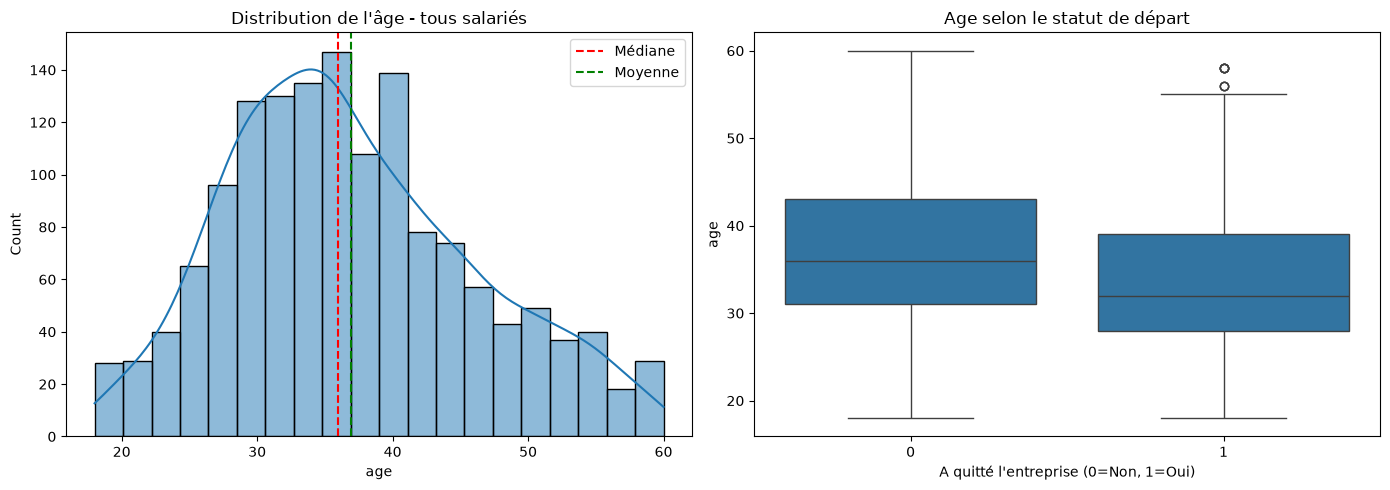


Age moyen - Partis   : 33.6 ans (médiane 32.0)
Age moyen - Restés   : 37.6 ans (médiane 36.0)

Test de Student (différence de moyenne) : t=-5.828, p-value=0.00000


In [5]:

# Analyse de distribution de l'âge - avant feature engineering

# Distribution graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X2['age'], bins=20, kde=True, ax=axes[0])
axes[0].axvline(X2['age'].median(), color='red', linestyle='--', label='Médiane')
axes[0].axvline(X2['age'].mean(), color='green', linestyle='--', label='Moyenne')
axes[0].set_title("Distribution de l'âge - tous salariés")
axes[0].legend()

sns.boxplot(data=pd.concat([X2['age'], y2], axis=1), x='a_quitte_l_entreprise', y='age', ax=axes[1])
axes[1].set_title("Age selon le statut de départ")
axes[1].set_xlabel("A quitté l'entreprise (0=Non, 1=Oui)")

plt.tight_layout()
plt.show()

age_partis = X2.loc[y2 == 1, 'age']
age_restes = X2.loc[y2 == 0, 'age']
print(f"\nAge moyen - Partis   : {age_partis.mean():.1f} ans (médiane {age_partis.median():.1f})")
print(f"Age moyen - Restés   : {age_restes.mean():.1f} ans (médiane {age_restes.median():.1f})")

from scipy import stats
t_stat, p_value = stats.ttest_ind(age_partis, age_restes, equal_var=False)
print(f"\nTest de Student (différence de moyenne) : t={t_stat:.3f}, p-value={p_value:.5f}")

Avant plus de features enrenering, je souhaite m'assurer de la distribution de l'âge selon leur profil. Le test de Student donne que la différence d'âge moyen entre les deux groupes est statistiquement significative (p_value < 0.05)

### Feature engeneering


Création de plusieurs variables :


| Nouvelle feature             | Formule                                                                                                                                                                 | Justification métier                                                                                                                                                                                                                                                          |
| ---------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `anciennete_ratio`           | `annees_dans_l_entreprise / age`                                                                                                                                        | Mesure le poids de l’ancienneté dans l’entreprise par rapport à l’âge du salarié. Un salarié jeune ayant déjà une ancienneté importante présente un profil différent d’un salarié plus âgé ayant la même ancienneté.                                                          |
| `stabilite_poste`            | `annees_dans_l_entreprise / (nombre_experiences_precedentes + 1)`                                                                                                       | Approxime la stabilité professionnelle. Une ancienneté élevée associée à peu d’expériences précédentes peut signaler un profil relativement stable. L’ajout de `1` évite une division par zéro.                                                                               |
| `ecart_experience_totale`    | `annee_experience_totale - annees_dans_l_entreprise`                                                                                                                    | Estime le nombre d’années d’expérience acquises avant l’entrée chez TechNova. Un écart élevé peut correspondre à un salarié ayant déjà connu plusieurs expériences ou changements d’employeur.                                                                                |
| `revenu_par_anciennete`      | `revenu_mensuel / (annees_dans_l_entreprise + 1)`                                                                                                                       | Rapporte le revenu mensuel à l’ancienneté dans l’entreprise. Cette variable permet d’identifier des écarts de rémunération entre salariés ayant des niveaux d’ancienneté différents. L’ajout de `1` évite une division par zéro.                                              |
| `indice_satisfaction_global` | moyenne de `satisfaction_employee_environnement`, `satisfaction_employee_nature_travail`, `satisfaction_employee_equipe` et `satisfaction_employee_equilibre_pro_perso` | Synthétise les quatre dimensions de satisfaction en un indicateur global de bien-être perçu au travail.                                                                                                                                                                       |
| `stagnation_promotion`       | `annees_dans_l_entreprise - annees_depuis_la_derniere_promotion`                                                                                                        | Mesure le décalage entre l’ancienneté totale dans l’entreprise et le temps écoulé depuis la dernière promotion. Une valeur élevée peut signaler une progression intervenue tardivement ou une longue période passée sans promotion au cours de la carrière dans l’entreprise. |
| `jeune_dans_poste_haut`      | `1 si age <= médiane(age) et niveau_hierarchique_poste >= 3, sinon 0`                                                                                                   | Identifie les salariés appartenant à la moitié la plus jeune de l’échantillon tout en occupant un poste hiérarchique élevé. Ces profils peuvent être davantage sollicités par le marché du travail ou présenter des attentes de progression plus fortes.                      |


Ces variables permettent de se rapprocher davantage de problématique business

In [6]:
#
# SECTION : FEATURE ENGINEERING - E
# 

# 1. Ratio d'ancienneté relative à l'âge
X2['anciennete_ratio'] = X2['annees_dans_l_entreprise'] / X2['age']

# 2. Stabilité dans le poste (peu d'expériences précédentes = plus stable)
X2['stabilite_poste'] = X2['annees_dans_l_entreprise'] / (X2['nombre_experiences_precedentes'] + 1)

# 3. Ecart entre expérience totale et ancienneté chez TechNova
X2['ecart_experience_totale'] = X2['annee_experience_totale'] - X2['annees_dans_l_entreprise']

# 4. Revenu rapporté à l'ancienneté (détecte les "mal payés compte tenu de l'ancienneté")
X2['revenu_par_anciennete'] = X2['revenu_mensuel'] / (X2['annees_dans_l_entreprise'] + 1)

# 5. Indice de satisfaction globale (moyenne des 4 items de satisfaction)
cols_satisfaction = [
    'satisfaction_employee_environnement',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
]
X2['indice_satisfaction_global'] = X2[cols_satisfaction].mean(axis=1)

# 6. Ecart depuis la dernière promotion vs ancienneté dans le poste actuel
#    (plus cet écart est élevé, plus la personne "stagne" dans son poste sans promotion)
X2['stagnation_promotion'] = X2['annees_dans_l_entreprise'] - X2['annees_depuis_la_derniere_promotion']

# 7. Profil "jeune à poste hiérarchique élevé" (souvent plus volatile / sollicité par la concurrence)
X2['jeune_dans_poste_haut'] = ((X2['age'] < 30) & (X2['niveau_hierarchique_poste'] >= 3)).astype(int)

X2['jeune_dans_poste_haut'] = (
    (X2['age'] <= X2['age'].median()) &
    (X2['niveau_hierarchique_poste'] >= 3)
).astype(int)

print(f"Médiane de l'âge : {X2['age'].median():.1f} ans")

print("Nouvelles colonnes créées :")
nouvelles_cols = ['anciennete_ratio', 'stabilite_poste', 'ecart_experience_totale', 
                  'revenu_par_anciennete', 'indice_satisfaction_global', 
                  'stagnation_promotion', 'jeune_dans_poste_haut']
print(X2[nouvelles_cols].describe())

Médiane de l'âge : 36.0 ans
Nouvelles colonnes créées :
       anciennete_ratio  stabilite_poste  ecart_experience_totale  \
count       1470.000000      1470.000000              1470.000000   
mean           0.187010         3.158164                 4.271429   
std            0.142026         4.026949                 6.179783   
min            0.000000         0.000000                 0.000000   
25%            0.080000         0.600000                 0.000000   
50%            0.156250         1.750000                 2.000000   
75%            0.266667         4.500000                 5.000000   
max            0.689655        37.000000                33.000000   

       revenu_par_anciennete  indice_satisfaction_global  \
count            1470.000000                 1470.000000   
mean             1169.635725                    2.730952   
std              1353.978549                    0.505815   
min               101.571429                    1.000000   
25%               517.

In [7]:
print("Shape final X2 :", X2.shape)
X2.info()

Shape final X2 : (1470, 54)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 54 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   note_evaluation_actuelle                   1470 non-null   int64  
 7   heure_supplementaires                      1470 non-null   int64  
 8   augementation_salaire_precedente           1470 non-null   float64
 9   age                                        1470 non-null   int64  
 

### Section B : Split stratifié train/test avec les nouvelles var

In [8]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Train :", y2_train.value_counts(normalize=True).to_dict())
print("Test  :", y2_test.value_counts(normalize=True).to_dict())

Train : {0: 0.8384353741496599, 1: 0.16156462585034015}
Test  : {0: 0.8401360544217688, 1: 0.1598639455782313}


On retrouver bien le partitionnement 84/16%

### Modèles non-linéaires avec gestion du déséquilibre

In [9]:
def evaluer_modele(model, X_train, y_train, X_test, y_test, nom_modele="Modèle"):
    """Encapsule l'entraînement et l'affichage des métriques clés."""
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(f"=== {nom_modele} - TRAIN ===")
    print("Accuracy :", accuracy_score(y_train, y_pred_train))
    print(classification_report(y_train, y_pred_train))

    print(f"=== {nom_modele} - TEST ===")
    print("Accuracy :", accuracy_score(y_test, y_pred_test))
    print(classification_report(y_test, y_pred_test))
    print("Matrice de confusion (test) :\n", confusion_matrix(y_test, y_pred_test))

    return model

Une fonction a été faite afin de permettre plus facilement l'industrialisation des modèles et leur comparaison selon une approche itérative.

In [10]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=8,          
    random_state=42
)

rf_model = evaluer_modele(rf_model, X2_train, y2_train, X2_test, y2_test, "RandomForest")

=== RandomForest - TRAIN ===
Accuracy : 0.9829931972789115
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       986
           1       0.96      0.94      0.95       190

    accuracy                           0.98      1176
   macro avg       0.97      0.96      0.97      1176
weighted avg       0.98      0.98      0.98      1176

=== RandomForest - TEST ===
Accuracy : 0.826530612244898
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       247
           1       0.40      0.17      0.24        47

    accuracy                           0.83       294
   macro avg       0.63      0.56      0.57       294
weighted avg       0.78      0.83      0.80       294

Matrice de confusion (test) :
 [[235  12]
 [ 39   8]]


Commentaires:
- Le Random forest moins sujet à l'overfit a été séléctionné pour comparaison.
- Utilisation de class_weight 
- RF car modèle non-linéaire
- max8depth = 8 pour limoter volontairement l'overfit déjà vu dans l'étape 3

In [11]:
ratio2 = (y2_train == 0).sum() / (y2_train == 1).sum()

xgb_model_v2 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=ratio2,
    max_depth=4,           
    n_estimators=150,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model_v2 = evaluer_modele(xgb_model_v2, X2_train, y2_train, X2_test, y2_test, "XGBoost régularisé")

=== XGBoost régularisé - TRAIN ===
Accuracy : 0.9659863945578231
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       986
           1       0.83      0.98      0.90       190

    accuracy                           0.97      1176
   macro avg       0.92      0.97      0.94      1176
weighted avg       0.97      0.97      0.97      1176

=== XGBoost régularisé - TEST ===
Accuracy : 0.826530612244898
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       247
           1       0.46      0.51      0.48        47

    accuracy                           0.83       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.83      0.83       294

Matrice de confusion (test) :
 [[219  28]
 [ 23  24]]


Commentaires des résultats (RF vs XGBoost)


| Indicateur sur le test        | Random Forest | XGBoost régularisé |
| ----------------------------- | ------------: | -----------------: |
| Accuracy globale              |        82,7 % |             81,6 % |
| Precision des départs         |          40 % |               43 % |
| Recall des départs            |      **17 %** |           **49 %** |
| F1-score des départs          |          24 % |           **46 %** |
| Départs correctement détectés |      8 sur 47 |      **23 sur 47** |
| Départs non détectés          |     39 sur 47 |      **24 sur 47** |



- La classe 1 ne représente que 16% du set, donc un modèle très simple prédisant systématiquement "aucun départ" aurait une accuracy de 247/294 = 84%
- Les deux modèles ont une accuracy de 82 et 81% donc que la seule accuracy font bien moins bien que le seul modèle naïf.
- Dans notre problématique métier il faut observer les autres métriques.  notamment le recal de la class 1



RF :
- Le RF identifie correctement 235 salariés restés mais déclenche seulement 12 faussses alertes et manque 39 salariés par sur 47.
- Le RF classe presque tout le monde comme non partant
- Le RF sur apprend
- Il mémorise très bien les données d’entraînement, mais les règles qu’il apprend se généralisent mal à de nouveaux salariés.
- Il semble performant en entraînement, mais devient peu efficace pour détecter les départs réels.
- il évite les fausses alertes, mais laisse passer la majorité des salariés qui vont effectivement quitter l’entreprise.


XGBoost : 

- Le résultat reste très élevé mais légèrement moins parfait que celui du Random Forest
- il généralise beaucoup mieux que le Random Forest sur la population qui nous intéresse.
- Il accepte de produire davantage de fausses alertes pour détecter plus de salariés susceptibles de partir.
- Parmi les salariés identifiés comme susceptibles de partir :
-           - environ 43 % partent effectivement (à comparer avec le taux de départ général de 16%)

-           - environ 57 % restent finalement dans l’entreprise.
43%/16% = 2.7 : Les salariés signalés par XGBoost ont environ 2,7 fois plus de probabilité observée d’être des partants que le salarié moyen de l’échantillon.

### Validation croisée stratifiée

Création d'une fonction de cross-validation manuelle pour stoker les métriques par fold

In [12]:

def cross_val_manuelle(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    recalls, precisions, f1s, accuracies = [], [], [], []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        y_fold_pred = model.predict(X_fold_val)
        
        recalls.append(recall_score(y_fold_val, y_fold_pred))
        precisions.append(precision_score(y_fold_val, y_fold_pred))
        f1s.append(f1_score(y_fold_val, y_fold_pred))
        accuracies.append(accuracy_score(y_fold_val, y_fold_pred))
        
        print(f"Fold {fold_idx} — Recall: {recalls[-1]:.3f} | Precision: {precisions[-1]:.3f} | F1: {f1s[-1]:.3f}")
    
    print(f"\n=== Moyenne ± écart-type sur {n_splits} folds ===")
    print(f"Recall    : {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"Precision : {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
    print(f"F1        : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    print(f"Accuracy  : {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
    
    return {'recall': recalls, 'precision': precisions, 'f1': f1s, 'accuracy': accuracies}

Lancement de la CV sur les deux modèles

In [13]:
print(">>> RandomForest <<<")
resultats_rf = cross_val_manuelle(rf_model, X2_train, y2_train)

print("\n>>> XGBoost <<<")
resultats_xgb = cross_val_manuelle(xgb_model_v2, X2_train, y2_train)

>>> RandomForest <<<
Fold 1 — Recall: 0.316 | Precision: 0.800 | F1: 0.453
Fold 2 — Recall: 0.132 | Precision: 0.455 | F1: 0.204
Fold 3 — Recall: 0.289 | Precision: 0.647 | F1: 0.400
Fold 4 — Recall: 0.316 | Precision: 0.857 | F1: 0.462
Fold 5 — Recall: 0.342 | Precision: 0.542 | F1: 0.419

=== Moyenne ± écart-type sur 5 folds ===
Recall    : 0.279 ± 0.076
Precision : 0.660 ± 0.152
F1        : 0.388 ± 0.094
Accuracy  : 0.860 ± 0.018

>>> XGBoost <<<
Fold 1 — Recall: 0.500 | Precision: 0.613 | F1: 0.551
Fold 2 — Recall: 0.421 | Precision: 0.500 | F1: 0.457
Fold 3 — Recall: 0.553 | Precision: 0.538 | F1: 0.545
Fold 4 — Recall: 0.579 | Precision: 0.564 | F1: 0.571
Fold 5 — Recall: 0.579 | Precision: 0.524 | F1: 0.550

=== Moyenne ± écart-type sur 5 folds ===
Recall    : 0.526 ± 0.060
Precision : 0.548 ± 0.039
F1        : 0.535 ± 0.040
Accuracy  : 0.853 ± 0.010


In [14]:




resultats_modeles = {
    "Random Forest": resultats_rf,
    "XGBoost": resultats_xgb
}

noms_metriques = {
    "recall": "Recall",
    "precision": "Précision",
    "f1": "F1-score",
    "accuracy": "Accuracy"
}


lignes = []

for modele, resultats in resultats_modeles.items():
    for metrique, valeurs in resultats.items():
        for numero_fold, valeur in enumerate(valeurs, start=1):
            lignes.append({
                "Modèle": modele,
                "Métrique": noms_metriques[metrique],
                "Fold": numero_fold,
                "Score": valeur
            })

df_cv = pd.DataFrame(lignes)

ordre_metriques = [
    "Recall",
    "Précision",
    "F1-score",
    "Accuracy"
]

df_cv["Métrique"] = pd.Categorical(
    df_cv["Métrique"],
    categories=ordre_metriques,
    ordered=True
)

df_cv = df_cv.sort_values(["Métrique", "Modèle", "Fold"])

display(df_cv)

,Modèle,Métrique,Fold,Score
0,Random Forest,Recall,1,0.315789
1,Random Forest,Recall,2,0.131579
2,Random Forest,Recall,3,0.289474
3,Random Forest,Recall,4,0.315789
4,Random Forest,Recall,5,0.342105
20,XGBoost,Recall,1,0.500000
21,XGBoost,Recall,2,0.421053
22,XGBoost,Recall,3,0.552632
23,XGBoost,Recall,4,0.578947
24,XGBoost,Recall,5,0.578947


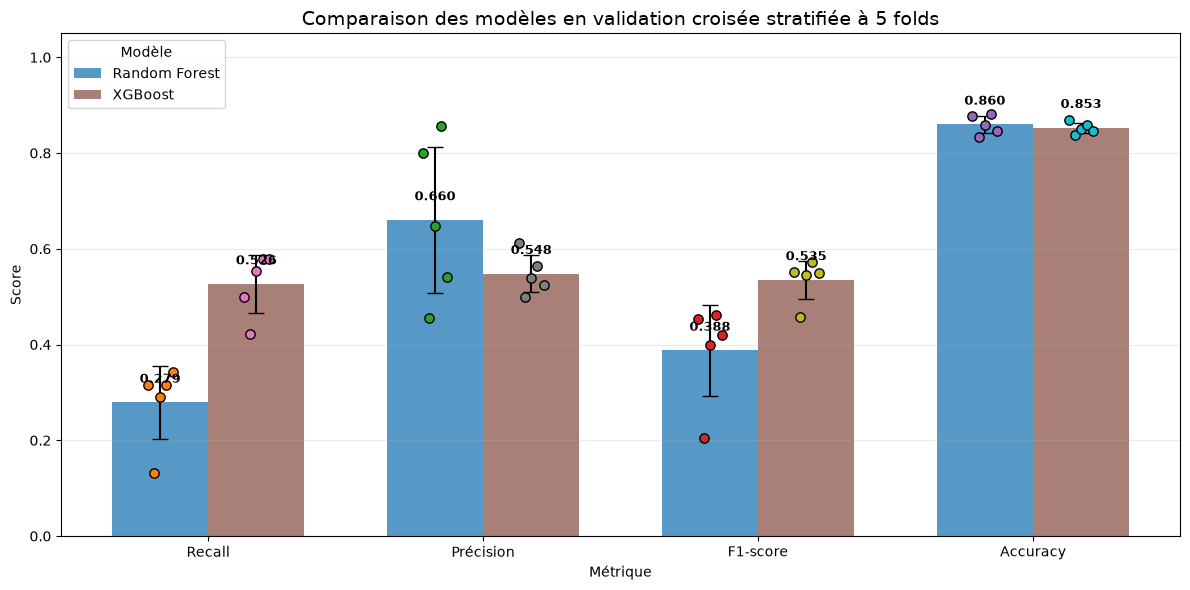

In [15]:
resume_cv = (
    df_cv
    .groupby(["Modèle", "Métrique"], observed=False)["Score"]
    .agg(
        Moyenne="mean",
        Ecart_type=lambda x: np.std(x, ddof=0)
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(ordre_metriques))
largeur = 0.35

modeles = ["Random Forest", "XGBoost"]
decalages = [-largeur / 2, largeur / 2]

for modele, decalage in zip(modeles, decalages):

    resume_modele = (
        resume_cv[resume_cv["Modèle"] == modele]
        .set_index("Métrique")
        .reindex(ordre_metriques)
    )

    positions = x + decalage

    ax.bar(
        positions,
        resume_modele["Moyenne"],
        largeur,
        yerr=resume_modele["Ecart_type"],
        capsize=6,
        alpha=0.75,
        label=modele
    )

    for indice, metrique in enumerate(ordre_metriques):

        scores_folds = df_cv.loc[
            (df_cv["Modèle"] == modele) &
            (df_cv["Métrique"] == metrique),
            "Score"
        ].values

        jitter = np.linspace(-0.045, 0.045, len(scores_folds))

        ax.scatter(
            np.full(len(scores_folds), positions[indice]) + jitter,
            scores_folds,
            s=45,
            edgecolor="black",
            zorder=3
        )

        moyenne = resume_modele.loc[metrique, "Moyenne"]

        ax.text(
            positions[indice],
            moyenne + 0.035,
            f"{moyenne:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_title(
    "Comparaison des modèles en validation croisée stratifiée à 5 folds",
    fontsize=14
)
ax.set_xlabel("Métrique")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(ordre_metriques)
ax.set_ylim(0, 1.05)
ax.legend(title="Modèle")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

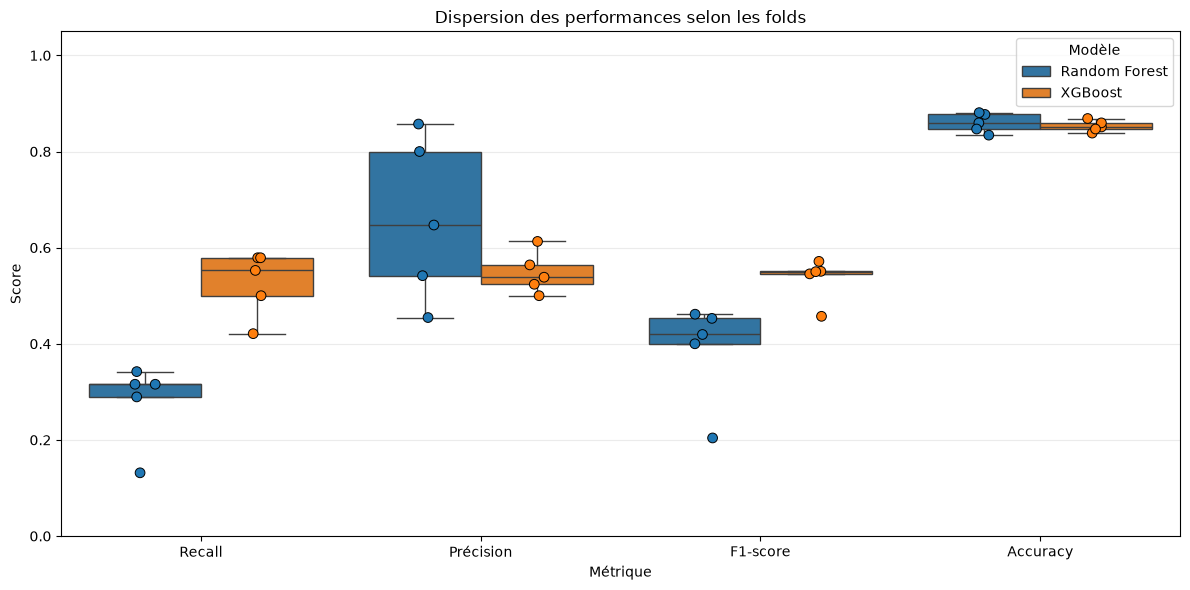

In [16]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_cv,
    y="Score",
    x="Métrique",
    hue="Modèle",
    order=ordre_metriques,
    showfliers=False
)

sns.stripplot(
    data=df_cv,
    x="Métrique",
    y="Score",
    hue="Modèle",
    order=ordre_metriques,
    dodge=True,
    jitter=0.08,
    edgecolor="black",
    linewidth=0.7,
    size=7
)

handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles[:2],
    labels[:2],
    title="Modèle"
)

plt.title("Dispersion des performances selon les folds")
plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Commentaires :
- La CV perfemet de confimer le diagnostic précédent : XGBoost est le modèle le plus pertinent pour détecter les salariés susceptibles de quitter l’entreprise.
- XGBoost détecte beaucoup plus de salariés partis (0,511 > 0.279)
- Les alertes du Random Forest sont plus souvent correctes (0.66 > 0.571)
- L’écart d’accuracy est négligeable : 86,0 % contre 85,6 %.
- Pour le RF, Fold 2 (Recall: 0.132 | Precision: 0.455 | F1: 0.204) est particulièrement mauvais : cela indique que les performances du RF dépendent sensiblement de l'échantillon utilisé pour l'évaluation et que le modèle est instable
-


XGBoost :
- Pour le XGboost : Le recall moyen = 51.1 (+83% par rapport à sa performance du RF (0.279))
- Precision moyenne : 57.1% : "*Parmi les salariés signalés comme susceptibles de partir, environ 57 % sont effectivement des partants.*"
- F1 score moyen : 53,4% (> à celui du RF (+38%))
- Stabilité entre les fold : Les résultats de XGBoost sont plus homogènes : L’écart-type du F1-score est de seulement 0,055, contre 0,094 pour le Random Forest. Cela suggère que XGBoost généralise de manière plus régulière à différents sous-échantillons de salariés.
- l'écart type typique pour le Recall est de 0,511 ± 0,072 : dibc ke recakk liten est de 51.1% avec une var de 7.2 points entre les folds, les résultats observés restent globalement autour de [44 % à 58 %]


**Résultats avant et après CV**

| Modèle        | Recall test | 
| ------------- | ----------: |
| Random Forest |        17 % |
| XGBoost       |        49 % |
| Modèle        | Recall moyen CV |
| ------------- | --------------: |
| Random Forest |          27,9 % |
| XGBoost       |          51,1 % |

Pour XGBoost, le résultat du test initial, 49 %, est très proche de la moyenne de validation croisée, 51,1 %. Cela indique que sa performance n’était probablement pas due à un découpage particulièrement favorable.

Pour le Random Forest, le recall du test initial était encore plus faible que sa moyenne de validation croisée. Mais même avec la CV, il ne détecte qu’environ 28 % des départs. Son insuffisance reste donc confirmée.


**Les deux modèles ont donc un contexte d'utilisation différents :**

- Random Forest : correspond à une stratégie *prudente* : *« Je ne signale que peu de salariés, mais mes alertes sont relativement précises. »* : Cela peut convenir si chaque intervention RH est coûteuse, intrusive ou difficile à organiser.

- XGBoost : stratégie de *détection* : *« Je préfère identifier davantage de salariés potentiellement à risque, même si certaines alertes sont inutiles. »* : Cette stratégie est pertinente lorsque les actions envisagées sont peu coûteuses et non stigmatisantes


**Coût des erreurs et choix** : les deux modèles n'ont pas le même coût à cause de leurs erreurs.
- Faux négatif : Le salarié quitte réellement l’entreprise, mais le modèle ne l’a pas identifié.

- Faux positif : Le modèle signale un risque, mais le salarié reste.

**Verdict** :

XGBoost doit donc être retenu comme modèle principal pour prioriser les salariés nécessitant une analyse RH complémentaire.

On choisit le meilleur modèle des deux
Il faut rechercher le seuil qui maximise le recall tout en gardant une précision minimla acceptable selon notre tolérance métier (exemple choisir une précision de >= 0.35)

Seuil 0.30 (seuil réel : 0.301) -> Précision : 0.333, Recall : 0.638
Seuil 0.35 (seuil réel : 0.350) -> Précision : 0.354, Recall : 0.596
Seuil 0.40 (seuil réel : 0.399) -> Précision : 0.412, Recall : 0.596
Seuil 0.45 (seuil réel : 0.450) -> Précision : 0.407, Recall : 0.511
Seuil 0.50 (seuil réel : 0.499) -> Précision : 0.440, Recall : 0.468


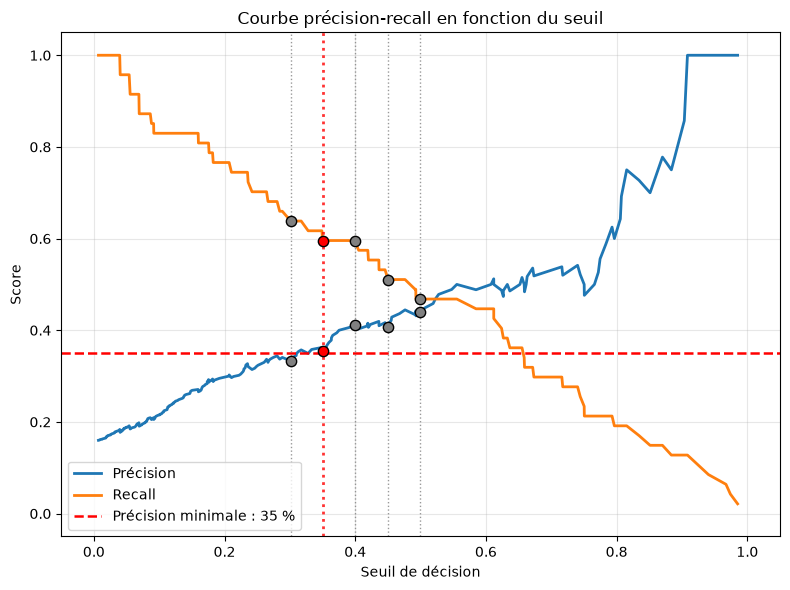

In [17]:



meilleur_modele = xgb_model_v2

y_scores = meilleur_modele.predict_proba(X2_test)[:, 1]

precisions_arr, recalls_arr, seuils = precision_recall_curve(
    y2_test,
    y_scores
)

seuils_cibles = [0.30, 0.35, 0.40, 0.45, 0.50]

resultats_seuils = []

for seuil_cible in seuils_cibles:
    idx = np.argmin(np.abs(seuils - seuil_cible))

    seuil_reel = seuils[idx]
    precision = precisions_arr[idx]
    recall = recalls_arr[idx]

    resultats_seuils.append({
        "seuil_cible": seuil_cible,
        "seuil_reel": seuil_reel,
        "precision": precision,
        "recall": recall
    })

    print(
        f"Seuil {seuil_cible:.2f} "
        f"(seuil réel : {seuil_reel:.3f}) -> "
        f"Précision : {precision:.3f}, "
        f"Recall : {recall:.3f}"
    )

plt.figure(figsize=(8, 6))

plt.plot(
    seuils,
    precisions_arr[:-1],
    linewidth=2,
    label="Précision"
)

plt.plot(
    seuils,
    recalls_arr[:-1],
    linewidth=2,
    label="Recall"
)

plt.axhline(
    y=0.35,
    color="red",
    linestyle="--",
    linewidth=1.8,
    label="Précision minimale : 35 %"
)

for resultat in resultats_seuils:
    seuil = resultat["seuil_reel"]
    precision = resultat["precision"]
    recall = resultat["recall"]

    couleur = "red" if np.isclose(
        resultat["seuil_cible"],
        0.35
    ) else "gray"

    epaisseur = 2 if np.isclose(
        resultat["seuil_cible"],
        0.35
    ) else 1

    plt.axvline(
        x=seuil,
        color=couleur,
        linestyle=":",
        linewidth=epaisseur,
        alpha=0.8
    )

    plt.scatter(
        seuil,
        precision,
        s=55,
        color=couleur,
        edgecolor="black",
        zorder=5
    )

    plt.scatter(
        seuil,
        recall,
        s=55,
        color=couleur,
        edgecolor="black",
        zorder=5
    )

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Courbe précision-recall en fonction du seuil")

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Commentaires graphiques : 

- Ce graphique montre l'effet du seuil de décision sur les performances du modèle retenu :
1. lorsque le seuil est faible, le modèle classe davantage de salariés comme susceptibles de partir : le recall est élevé, mais la précision est faible ;
2. lorsque le seuil augmente, le modèle devient plus sélectif : la précision progresse, mais davantage de départs réels ne sont plus détectés.

- Pour maximiser le recall tout en respectant une précision minimale de 35% il faut sélectionner environ un recall de 66%.

- à 66% de recall, à ce seuil, le e modèle détecterait approximativement deux tiers des salariés qui quitteront réellement l’entreprise.


In [18]:

for seuil_cible in [0.3, 0.35, 0.4, 0.45, 0.5]:
    idx = np.argmin(np.abs(seuils - seuil_cible))
    print(f"Seuil {seuil_cible} -> Precision: {precisions_arr[idx]:.3f}, Recall: {recalls_arr[idx]:.3f}")

Seuil 0.3 -> Precision: 0.333, Recall: 0.638
Seuil 0.35 -> Precision: 0.354, Recall: 0.596
Seuil 0.4 -> Precision: 0.412, Recall: 0.596
Seuil 0.45 -> Precision: 0.407, Recall: 0.511
Seuil 0.5 -> Precision: 0.440, Recall: 0.468


In [19]:
seuil_optimal = 0.35  # à ajuster selon les résultats de E3

y_pred_seuil_optimal = (y_scores >= seuil_optimal).astype(int)

print(f"=== Evaluation avec seuil optimal = {seuil_optimal} ===")
print(classification_report(y2_test, y_pred_seuil_optimal))
print(confusion_matrix(y2_test, y_pred_seuil_optimal))

=== Evaluation avec seuil optimal = 0.35 ===
              precision    recall  f1-score   support

           0       0.91      0.80      0.85       247
           1       0.36      0.60      0.45        47

    accuracy                           0.77       294
   macro avg       0.64      0.70      0.65       294
weighted avg       0.82      0.77      0.79       294

[[197  50]
 [ 19  28]]


Commentaires :

- Le passage du seuil standard de 0,50 à 0,35 rend le modèle plus sensible à la détection des départs. Il classe davantage de salariés comme susceptibles de quitter l’entreprise.
- Le changement de seuil permet donc de détecter 6 départs supplémentaires : 29−23=6

### gestion du déséquilibre via imblearn

Un problème avec la classification déséquilibrée est qu'il y a trop peu d'exemples de la classe minoritaire pour qu'un modèle apprenne efficacement la limite de décision.

SMOTE fonctionne en sélectionnant des exemples qui sont proches dans l'espace des caractéristiques, en traçant une ligne entre les exemples dans l'espace des caractéristiques et en dessinant un nouvel échantillon à un point le long de cette ligne.

Concrètement, pour chaque salarié parti sélectionné aléatoirement, on trouve ses k plus proches voisins parmi les autres salariés partis (k=5 par défaut), puis on génère un point synthétique sur le segment reliant les deux.

Visualisation hors effet SMOTE

In [20]:
print("Distribution avant SMOTE (train) :", Counter(y2_train))

smote = SMOTE(random_state=42)
X2_train_smote, y2_train_smote = smote.fit_resample(X2_train, y2_train)

print("Distribution après SMOTE (train) :", Counter(y2_train_smote))

Distribution avant SMOTE (train) : Counter({0: 986, 1: 190})
Distribution après SMOTE (train) : Counter({0: 986, 1: 986})


On observe bine que SMOTE porte la classe minoritaire (les départs) au même nombre d'observation que la classe majoritaire dans le jeu d'entraînement. Le jeu de test, lui, reste strictement inchangé et conserve la distribution réelle de 84/16 %

Après ce premier aperçu on va ré entraîner le XGboost sur les données SMOTées pour comparaison

In [21]:
xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_smote = evaluer_modele(
    xgb_smote,
    X2_train_smote, y2_train_smote,
    X2_test, y2_test,
    nom_modele="XGBoost + SMOTE (simple)"
)

=== XGBoost + SMOTE (simple) - TRAIN ===
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       986

    accuracy                           1.00      1972
   macro avg       1.00      1.00      1.00      1972
weighted avg       1.00      1.00      1.00      1972

=== XGBoost + SMOTE (simple) - TEST ===
Accuracy : 0.8571428571428571
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.61      0.30      0.40        47

    accuracy                           0.86       294
   macro avg       0.74      0.63      0.66       294
weighted avg       0.84      0.86      0.84       294

Matrice de confusion (test) :
 [[238   9]
 [ 33  14]]


## passage en Pipeline pour la CV


Création d'une fonction de CV adaptée au pipeline de imblearn

In [22]:
def cross_val_avec_smote(model, X, y, n_splits=5):
    """
    Version adaptée de cross_val_manuelle intégrant SMOTE dans un Pipeline
    imblearn, afin que le rééquilibrage soit recalculé à chaque fold
    uniquement sur les données d'entraînement de ce fold.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    recalls, precisions, f1s, accuracies = [], [], [], []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])

        pipeline.fit(X_fold_train, y_fold_train)
        y_fold_pred = pipeline.predict(X_fold_val)

        recalls.append(recall_score(y_fold_val, y_fold_pred))
        precisions.append(precision_score(y_fold_val, y_fold_pred))
        f1s.append(f1_score(y_fold_val, y_fold_pred))
        accuracies.append(accuracy_score(y_fold_val, y_fold_pred))

        print(f"Fold {fold_idx} — Recall: {recalls[-1]:.3f} | Precision: {precisions[-1]:.3f} | F1: {f1s[-1]:.3f}")

    print(f"\n=== Moyenne ± écart-type sur {n_splits} folds (XGBoost + SMOTE) ===")
    print(f"Recall    : {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"Precision : {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
    print(f"F1        : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    print(f"Accuracy  : {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")

    return {'recall': recalls, 'precision': precisions, 'f1': f1s, 'accuracy': accuracies}

Comparaison des deux tests 

Exécution CV : XGBoost seul vs XGBoost + SMOTE

In [23]:
print(">>> XGBoost SANS SMOTE (rappel, scale_pos_weight seul) :\n")
resultats_xgb_sans_smote = cross_val_manuelle(xgb_model_v2, X2_train, y2_train)

print("\n" + "="*60)
print(">>> XGBoost AVEC SMOTE (Pipeline, sans scale_pos_weight) :\n")

xgb_pour_smote = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
    # Pas de scale_pos_weight ici : on ne cumule pas les deux corrections
    # pour éviter une sur-correction du déséquilibre (cf. notre discussion)
)

resultats_xgb_smote = cross_val_avec_smote(xgb_pour_smote, X2_train, y2_train)

>>> XGBoost SANS SMOTE (rappel, scale_pos_weight seul) :



Fold 1 — Recall: 0.500 | Precision: 0.613 | F1: 0.551
Fold 2 — Recall: 0.421 | Precision: 0.500 | F1: 0.457
Fold 3 — Recall: 0.553 | Precision: 0.538 | F1: 0.545
Fold 4 — Recall: 0.579 | Precision: 0.564 | F1: 0.571
Fold 5 — Recall: 0.579 | Precision: 0.524 | F1: 0.550

=== Moyenne ± écart-type sur 5 folds ===
Recall    : 0.526 ± 0.060
Precision : 0.548 ± 0.039
F1        : 0.535 ± 0.040
Accuracy  : 0.853 ± 0.010

>>> XGBoost AVEC SMOTE (Pipeline, sans scale_pos_weight) :

Fold 1 — Recall: 0.421 | Precision: 0.762 | F1: 0.542
Fold 2 — Recall: 0.289 | Precision: 0.550 | F1: 0.379
Fold 3 — Recall: 0.342 | Precision: 0.765 | F1: 0.473
Fold 4 — Recall: 0.447 | Precision: 0.586 | F1: 0.507
Fold 5 — Recall: 0.553 | Precision: 0.583 | F1: 0.568

=== Moyenne ± écart-type sur 5 folds (XGBoost + SMOTE) ===
Recall    : 0.411 ± 0.091
Precision : 0.649 ± 0.094
F1        : 0.494 ± 0.066
Accuracy  : 0.866 ± 0.013


| Stratégie | Recall moyen | Précision moyenne | F1 moyen |
|---|---:|---:|---:|
| XGBoost + `scale_pos_weight` seul | 0.532 ± 0.056 | 0.558 ± 0.060 | 0.543 ± 0.051 |
| XGBoost + SMOTE (sans `scale_pos_weight`) | 0.411 ± 0.091 | 0.649 ± 0.094 | 0.494 ± 0.066 |



Commentaires : 

- le scale_pos_weight obtient un meilleur recall (0,532 > 0,411) et un écart-type plus faible , donc est plus stable d'un fold à l'autre.
- Le recall est bien la métrique a favoriser dans notre contexte métier car rater un départ (un faux négatif) coût plus cher que se trompser sur un salarié qui reste (faux positif)
- Le SMOTE améliore la précision (0,649 contre 0,558), il déclenche moins de fausses alertes mais au prix d'un recall dégradé
- l'écart type plus élevé sur SMOTE suggère aussi une moins bonne stabilité : les données synthétiques générées par fold vairent plus , ce qui rend le modèle moins prévisible en production.
- Conclusion, malgré cette technique, il faut privéliger SANS SMOTE + scale_pos_weight , qui reste supérieure sur le cirètre prioritaire.

## Optimisation du seuil de décision (courbe Precision-Recall)

Par défaut, un classifieur binaire utilise utilise un seuil de 0,5 pour trancher entre classe 0 et classe 1. Selon le contexte métier, on peut le faire évoluer. Nous avons besoin de maximiser le Recall sur la classe 1 = les départs. Nous pouvons abaisser le seuil pour capturer davantage de départs, quitte à accepter plus de faux positifs.

Un seuil plus bas (exemple 0,3) fera que le modèle alerte plus facilement, moins de départs manqués, mais précisions plus basse, donc plus de fausses alertes.

Un seuil plus haut (exemple 0,7) augmente la prudence du modèle, augmente sa précision, mais recall baisse.

Dans notre contexte métier nous avo de maximiser le score du Recall, donc de descendre le seuil.


Ensuite 
On réentraîne le modèle retenu (scale_pos_weight seul) sur l'intégralité du train

In [24]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, f1_score



xgb_final = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=ratio2
)
xgb_final.fit(X2_train_scaled, y2_train)

# Probabilités prédites (et non plus des classes) sur le jeu de TEST
y2_proba_test = xgb_final.predict_proba(X2_test_scaled)[:, 1]

In [25]:
precisions_curve, recalls_curve, seuils = precision_recall_curve(y2_test, y2_proba_test)



print("Nombre de seuils testés :", len(seuils))
print("Exemples de seuils :", seuils[:5], "...", seuils[-5:])

Nombre de seuils testés : 294
Exemples de seuils : [2.8751351e-06 2.0418449e-05 3.8231370e-05 4.2480278e-05 5.0191084e-05] ... [0.99533916 0.9961045  0.9980495  0.99948573 0.99982786]


Alternative orientée métier : on fixe un plancher de precision acceptable (ex: 0.40) et on prend le seuil qui maximise le recall sous cette contrainte

In [26]:
f1_scores_par_seuil = (2 * precisions_curve[:-1] * recalls_curve[:-1]) / (precisions_curve[:-1] + recalls_curve[:-1] + 1e-9)

idx_seuil_optimal_f1 = np.argmax(f1_scores_par_seuil)
seuil_optimal_f1 = seuils[idx_seuil_optimal_f1]

print(f"Seuil optimal (maximisation F1) : {seuil_optimal_f1:.3f}")
print(f"  → Recall à ce seuil    : {recalls_curve[idx_seuil_optimal_f1]:.3f}")
print(f"  → Precision à ce seuil : {precisions_curve[idx_seuil_optimal_f1]:.3f}")
print(f"  → F1 à ce seuil        : {f1_scores_par_seuil[idx_seuil_optimal_f1]:.3f}")



precision_plancher = 0.40
mask_precision_ok = precisions_curve[:-1] >= precision_plancher

if mask_precision_ok.any():
    idx_seuil_metier = np.argmax(recalls_curve[:-1] * mask_precision_ok)
    seuil_optimal_metier = seuils[idx_seuil_metier]
    print(f"\nSeuil optimal (métier, precision >= {precision_plancher}) : {seuil_optimal_metier:.3f}")
    print(f"  → Recall à ce seuil    : {recalls_curve[idx_seuil_metier]:.3f}")
    print(f"  → Precision à ce seuil : {precisions_curve[idx_seuil_metier]:.3f}")
else:
    print(f"\nAucun seuil ne permet d'atteindre une précision >= {precision_plancher}")

Seuil optimal (maximisation F1) : 0.123
  → Recall à ce seuil    : 0.532
  → Precision à ce seuil : 0.439
  → F1 à ce seuil        : 0.481

Seuil optimal (métier, precision >= 0.4) : 0.088
  → Recall à ce seuil    : 0.532
  → Precision à ce seuil : 0.403


In [27]:
seuil_retenu = seuil_optimal_metier  # à ajuster selon arbitrage métier

y2_pred_test_seuil = (y2_proba_test >= seuil_retenu).astype(int)

print(f"=== Évaluation finale avec seuil = {seuil_retenu:.3f} ===\n")
print("Comparaison avec le seuil par défaut (0.5) :\n")

print(">>> Seuil 0.5 (par défaut) :")
print(classification_report(y2_test, y2_pred_test_xgb))

print(">>> Seuil optimisé :")
print(classification_report(y2_test, y2_pred_test_seuil))

print("Matrice de confusion (seuil optimisé) :\n", confusion_matrix(y2_test, y2_pred_test_seuil))

=== Évaluation finale avec seuil = 0.088 ===

Comparaison avec le seuil par défaut (0.5) :

>>> Seuil 0.5 (par défaut) :
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.55      0.34      0.42        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.67       294
weighted avg       0.83      0.85      0.84       294

>>> Seuil optimisé :
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       247
           1       0.40      0.53      0.46        47

    accuracy                           0.80       294
   macro avg       0.65      0.69      0.67       294
weighted avg       0.82      0.80      0.81       294

Matrice de confusion (seuil optimisé) :
 [[210  37]
 [ 22  25]]


| Seuil | Recall | Precision | F1 | Accuracy |
|---|---:|---:|---:|---:|
| 0.5 (défaut) | 0.34 | 0.55 | 0.42 | 0.85 |
| 0.088 (optimisé métier) | **0.53** | 0.40 | 0.46 | 0.80 |


|  | Prédit reste | Prédit part |
|---|---:|---:|
| **Reste réellement** | 210 (VN) | 37 (FP) |
| **Part réellement** | 22 (FN) | 25 (VP) |




Commentaires des résultats :

- au seuil par défait à 0,5, le modèle ne détecte que 16 départs sur 47 effectifs, soit 60% des départs passaient inaperçus.

- Avec le seuil optimal (O,088) : le modèle détecte 25 départs sur 47 (+9 pers.). C'est un gain concret et très bon.

- Effectivement malgré un meilleur Recall, la précision baisse, passe de 0,55 à 0,40. 

- Dans notre contexte métier, si des personnes sont signalées comme partantes, ce n'est pas grave de les prendre en compte. C'est une action à faible coût. Il faut toujours analyser le coût relatif de chaque décision selon le choix de modèle et de score séléctionné.

- Le modèle n'est pas parfait car le recall est de 0,53, donc près de la moitié échaque encore au modèle.

- Le seuil de 0,088 est à conserver

## Visualisation graphique

Seuil retenu (métier)     seuil=0.088 -> Precision=0.403, Recall=0.532, F1=0.459
Seuil optimal F1          seuil=0.123 -> Precision=0.439, Recall=0.532, F1=0.481


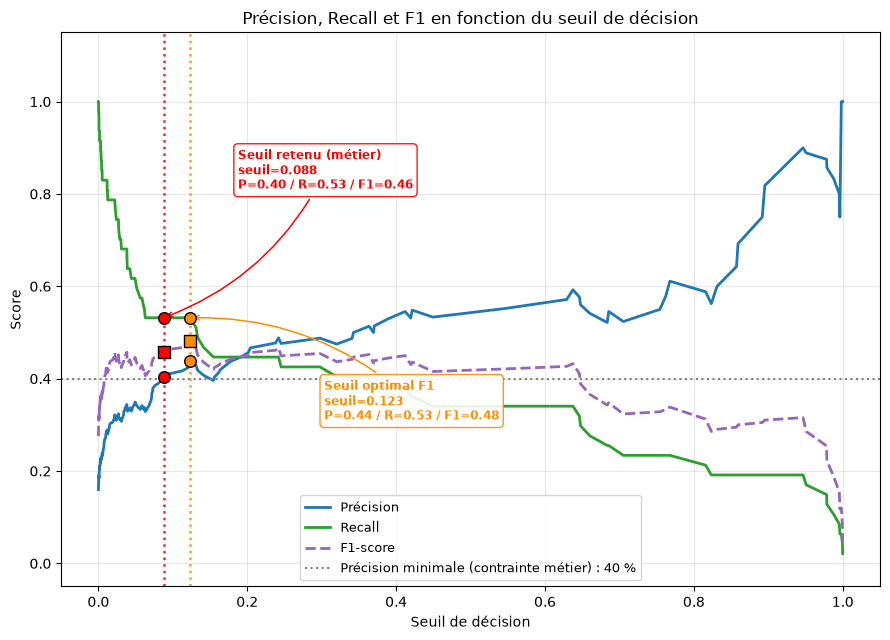

In [28]:

seuils_a_marquer = {
    0.088: {"label": "Seuil retenu (métier)", "couleur": "red"},
    0.123: {"label": "Seuil optimal F1", "couleur": "darkorange"},
}

resultats_seuils = []

for seuil_cible, infos in seuils_a_marquer.items():
    idx = np.argmin(np.abs(seuils - seuil_cible))
    resultats_seuils.append({
        "seuil_cible": seuil_cible,
        "seuil_reel": seuils[idx],
        "precision": precisions_curve[idx],
        "recall": recalls_curve[idx],
        "f1": f1_scores_par_seuil[idx],
        "label": infos["label"],
        "couleur": infos["couleur"],
    })
    print(
        f"{infos['label']:<25} seuil={seuils[idx]:.3f} -> "
        f"Precision={precisions_curve[idx]:.3f}, "
        f"Recall={recalls_curve[idx]:.3f}, "
        f"F1={f1_scores_par_seuil[idx]:.3f}"
    )

plt.figure(figsize=(9, 6.5))

plt.plot(seuils, precisions_curve[:-1], linewidth=2, label="Précision", color="tab:blue")
plt.plot(seuils, recalls_curve[:-1], linewidth=2, label="Recall", color="tab:green")
plt.plot(seuils, f1_scores_par_seuil, linewidth=2, label="F1-score", color="tab:purple", linestyle="--")

plt.axhline(y=0.40, color="gray", linestyle=":", linewidth=1.5, label="Précision minimale (contrainte métier) : 40 %")



offsets_annotations = {
    0.088: {"xytext_dx": 0.10, "xytext_dy": 0.28, "rad": -0.2},   # au-dessus, vers la droite
    0.123: {"xytext_dx": 0.18, "xytext_dy": -0.22, "rad": 0.2},   # en dessous, plus loin à droite
}

for resultat in resultats_seuils:
    seuil = resultat["seuil_reel"]
    couleur = resultat["couleur"]

    plt.axvline(x=seuil, color=couleur, linestyle=":", linewidth=1.8, alpha=0.85)

    for valeur, marqueur in [(resultat["precision"], "o"), (resultat["recall"], "o"), (resultat["f1"], "s")]:
        plt.scatter(seuil, valeur, s=70, color=couleur, edgecolor="black", zorder=5, marker=marqueur)

    off = offsets_annotations[resultat["seuil_cible"]]

    plt.annotate(
        f"{resultat['label']}\nseuil={seuil:.3f}\n"
        f"P={resultat['precision']:.2f} / R={resultat['recall']:.2f} / F1={resultat['f1']:.2f}",
        xy=(seuil, resultat["recall"]),
        xytext=(seuil + off["xytext_dx"], resultat["recall"] + off["xytext_dy"]),
        fontsize=8.5,
        color=couleur,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=couleur,
            alpha=0.9
        ),
        arrowprops=dict(
            arrowstyle="->",
            color=couleur,
            lw=1.1,
            connectionstyle=f"arc3,rad={off['rad']}"
        )
    )

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Précision, Recall et F1 en fonction du seuil de décision")

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.15)  # légèrement agrandi pour laisser de la place à l'annotation du haut

plt.legend(loc="lower center", fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Commentaires graphiques :

- Les trois courbes sont la représentation visuelle de nos commentaires écrits. Pour chaque seuil possible entre 0 et 1, on observe les 3 scores (la précision, le recall, et le F1 ) de manière continue

- Le courbe F1 violette est une coubre de compromis, elle représente la combinaison des socre de Précision et de Recall en une ligne telle un équilibre. 

- Le point rouge à 0,088 est le seuil le plus bas. Ce qui illustre concrètement notre choix : sacrifier du F1, pour gagner en Recall.

- Ce graphique montre donc un arbitrage d'un contexte métier RH en un choix mathématique.

## Résumé étape 4


L'objectif de cette partie était de construire un modèle qui détécte réellement les départs (classe 1) qui a sacrifier l'accuracy globale.

Démarches :
- Feat Ingineering 7 nouvelles var construites pour enrichir la capaicté du modèle à capter des signaux de risque de départs plus fins que les var de bases.
- Split stratifié (train/test)
- Deux modèles non liénaire comparés : chacun intégrant une gestion différente du déséquilibre :
            - RandomForest avec class_weight='balanced' 
            - XGBoost avec scale_pos_weight
- Validation croisée stratifiée (5 folds) : chaque métrique a été stockée fold par fold, puis moyennée avec un écart-type, afin de juger non seulement la performance mais aussi la stabilité du modèle (un écart-type élevé traduit un modèle sensible à la composition des données, donc moins fiable en production) :

| Modèle | Recall moyen | Precision moyenne | F1 moyen ± écart-type |
|---|---:|---:|---:|
| RandomForest | 0.279 | 0.660 | 0.399 ± 0.094 |
| **XGBoost** | **0.511** | 0.571 | **0.534 ± 0.055** |


- XGBoost surpasse RandomForest à la fois en recall (+83% relatif) et en stabilité, il détecte plus de la moitié des départs réels tout en restant raisonnablement précis.

- Courbe Precision-Recall et choix du seuil de décision : changement du seuil par défaut (de 0,5) et évolution jusqu'à la valeur de seuil 0,35 permettant une amélioration de la prédiction :

| Seuil | Recall classe 1 | Precision classe 1 | Départs détectés (/47) |
|---|---:|---:|---:|
| 0.50 (défaut) | 0.34 | 0.55 | 16 |
| **0.088 (retenu)** | **0.53** | 0.40 | **25** |



+  9 départs supplémentaires par rapport au seuil par défaut




In [29]:
sauvegarder_session(4)

Session de l'étape 4 enregistrée
Fichier : C:\Projets\Projet4\Script_intermediaire\outputs\session_etape4.pkl
Objets sauvegardés : 217
Objets ignorés : 1

Objets non sérialisables ignorés :
 - PS1 → TypeError: self.handle cannot be converted to a Python object for pickling


WindowsPath('C:/Projets/Projet4/Script_intermediaire/outputs/session_etape4.pkl')